In [498]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]━ 1/2 [kagglehub]


In [458]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [460]:
from extract_embedding import FaceEmbedder
from face_recognizer import FaceRecognizer
from train_model import FaceTrainer

In [462]:
embedder = FaceEmbedder()
embedder.process_dataset(dataset_dir="dataset")
embedder.save_embeddings(output_file="embeddings.pkl")

[INFO] BASE_DIR:  /Users/ypark/Desktop/FYDP-ADAD/faceRec
[INFO] Loading face detection model...
[INFO] Processing dataset...
[INFO] Processing person: YoonheePark
[INFO] Processing person: DanielSzelepcsenyi
[INFO] Processing person: VivienYu
[INFO] Processing person: HaileyKim
[INFO] Extracted 358 embeddings
[INFO] Saving 358 embeddings to embeddings.pkl...
[INFO] Done!


In [463]:
lfw = fetch_lfw_people(min_faces_per_person=0, resize=0.5)

In [500]:
import kagglehub

path = kagglehub.dataset_download("selfishgene/youtube-faces-with-facial-keypoints")

print("Dataset downloaded to:", path)

 11%|████▏                                 | 1.79G/16.2G [00:38<05:11, 49.8MB/s]


KeyboardInterrupt: 

### Trial 1 Data Load

In [277]:
from collections import defaultdict
from sklearn.datasets import fetch_lfw_people
import random

# Download LFW dataset (only people with at least 50 images to keep it manageable)
lfw = fetch_lfw_people(min_faces_per_person=5, resize=0.5)  # resize to 50% for speed

# Parameters
MIN_IMAGES_PER_PERSON = 5
MAX_IMAGES_PER_PERSON = 6

# Store embeddings and labels
lfw_embeddings = []
lfw_labels = []

# Keep track of how many images we’ve added per person
person_to_indices = defaultdict(list)

# First, gather all indices for each person
for idx, label_idx in enumerate(lfw.target):
    person_name = lfw.target_names[label_idx]
    person_to_indices[person_name].append(idx)

# Randomly select 5–10 images per person
for person_name, indices in person_to_indices.items():
    n_select = min(len(indices), MAX_IMAGES_PER_PERSON)
    n_select = max(n_select, MIN_IMAGES_PER_PERSON)  # ensure at least MIN_IMAGES

    selected_indices = random.sample(indices, n_select)
    
    for idx in selected_indices:
        img = lfw.images[idx]
        label_idx = lfw.target[idx]

        # Convert grayscale → BGR if needed
        if img.ndim == 2:
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
            img_bgr = img

        # Resize to SSD input size for face detection
        img_bgr = cv2.resize(img_bgr, (300, 300))

        # Generate embedding
        embedding = embedder.get_embedding(img_bgr)
        lfw_embeddings.append(embedding)
        lfw_labels.append(label_idx)

print(f"[INFO] Extracted {len(lfw_embeddings)} embeddings from LFW (5–10 per person)")

[INFO] Extracted 2426 embeddings from LFW (5–10 per person)


# Without unknown identities

## Load Data

In [332]:
def load_lfw_dataset(num_people, min_images_per_person):

    from sklearn.datasets import fetch_lfw_people
    import random
    import cv2
    import numpy as np
    from collections import defaultdict

    # Randomly shuffle dataset indices first
    all_indices = list(range(len(lfw.images)))
    random.shuffle(all_indices)

    # Map person -> indices
    person_to_indices = defaultdict(list)

    for idx in all_indices:
        label_idx = lfw.target[idx]
        person_name = lfw.target_names[label_idx]
        person_to_indices[person_name].append(idx)

    # Filter people with enough images
    eligible_people = [
        p for p, idxs in person_to_indices.items()
        if len(idxs) >= min_images_per_person
    ]

    if len(eligible_people) < num_people:
        return [], []

    # Randomly choose people
    selected_people = random.sample(eligible_people, num_people)

    embeddings = []
    labels = []

    for person_name in selected_people:

        indices = person_to_indices[person_name]

        # Randomly select images
        selected_indices = random.sample(indices, min_images_per_person)

        for idx in selected_indices:

            img = lfw.images[idx]

            if img.ndim == 2:
                img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            else:
                img_bgr = img

            img_bgr = cv2.resize(img_bgr, (300, 300))

            embedding = embedder.get_embedding(img_bgr)

            embeddings.append(embedding)
            labels.append(person_name)

    return embeddings, labels

## LFW Investigation

In [269]:
from collections import defaultdict

counts = defaultdict(int)

# lfw_labels are numeric (label indices)
for label in lfw_labels:
    person_name = lfw.target_names[label]
    counts[person_name] += 1

# Print counts per person
for person, count in counts.items():
    print(f"{person}: {count} images")

James Blake: 10 images
Bill Simon: 10 images
Tony Blair: 10 images
Andre Agassi: 10 images
Jennifer Lopez: 10 images
Paradorn Srichaphan: 10 images


## Train

In [370]:
def train_model(x, y):
    import numpy as np
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.linear_model import LogisticRegression

    # Use the input data, not global variables
    X = np.array(x)
    y = np.array(y)
    
    # ----------------- Encode labels -----------------
    le = LabelEncoder()
    y_enc = le.fit_transform(y)  # now labels are 0..n_classes-1
    
    # ----------------- Train/test split -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
    )
    
    print(f"[INFO] Number of classes: {len(le.classes_)}")
    print(f"[INFO] Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

    # ----------------- Train multiple classifiers -----------------
    classifiers = {
        "SVM": SVC(C=1.0, kernel="linear", probability=True), #, class_weight = 'balanced'
        "KNN": KNeighborsClassifier(n_neighbors=3),
        "LogReg": LogisticRegression(max_iter=500)
    }

    # Return classifiers and the split/test data so you can evaluate
    return classifiers, X_train, X_test, y_train, y_test, le

## Predict

In [372]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def predict(name, clf, X_train, X_test, y_train, y_test):
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    error_rate = 1 - accuracy
    
    print("====================================")
    print(f"Classifier: {name}")
    print(f"Type: {type(clf).__name__}")
    if hasattr(clf, 'get_params'):
        print(f"Parameters: {clf.get_params()}")
    print("------------------------------------")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision (macro): {precision*100:.2f}%")
    print(f"Recall (macro): {recall*100:.2f}%")
    print(f"Error rate: {error_rate*100:.2f}%")
    print("====================================\n")

    return accuracy, precision, recall, error_rate

In [380]:
num_people = 50
min_images_per_person = 5

print(f"number of people: {num_people}")
embedding, labels = load_lfw_dataset(num_people, min_images_per_person) 

classifiers, X_train, X_test, y_train, y_test, le = train_model(embedding, labels)

for name, clf in classifiers.items():
    accuracy, precision, recall, error_rate = predict(
        name, clf, X_train, X_test, y_train, y_test
    )

number of people: 50
[INFO] Number of classes: 50
[INFO] Training samples: 200, Testing samples: 50
Classifier: SVM
Type: SVC
Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------
Accuracy: 20.00%
Precision (macro): 13.50%
Recall (macro): 20.00%
Error rate: 80.00%

Classifier: KNN
Type: KNeighborsClassifier
Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
------------------------------------
Accuracy: 10.00%
Precision (macro): 8.40%
Recall (macro): 10.00%
Error rate: 90.00%

Classifier: LogReg
Type: LogisticRegression
Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'int

## Find the right parameter to maximize basic classifier

In [406]:
import pandas as pd

range_num_people = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50]
range_min_images_per_person = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50]

results_df = pd.DataFrame(columns=[
    "num_people",
    "images_per_person",
    "classifier",
    "classifier_info",
    "accuracy",
    "precision_macro",
    "error_rate"
])

for num_people in range_num_people:
    for min_images_per_person in range_min_images_per_person:

        embedding, labels = load_lfw_dataset(num_people, min_images_per_person)

        print("[INFO] Min Images Per Person: ", min_images_per_person)
        
        # Skip if dataset not available
        if len(embedding) == 0:
            continue

        num_classes = len(set(labels))
        num_samples = len(labels)
        test_size = int(num_samples * 0.2)

        if test_size < num_classes:
            print("[INFO] Skipping configuration: test set too small")
            continue

        classifiers, X_train, X_test, y_train, y_test, le = train_model(embedding, labels)

        for name, clf in classifiers.items():

            accuracy, precision, recall, error_rate = predict(
                name, clf, X_train, X_test, y_train, y_test
            )

            row = pd.DataFrame([{
                "num_people": num_people,
                "images_per_person": min_images_per_person,
                "classifier": name,
                "classifier_info": f"Type: {type(clf).__name__}, Parameters: {clf.get_params()}",
                "accuracy": accuracy,
                "precision_macro": precision,
                "error_rate": error_rate
            }])

            results_df = pd.concat([results_df, row], ignore_index=True)

[INFO] Min Images Per Person:  3
[INFO] Skipping configuration: test set too small
[INFO] Min Images Per Person:  5
[INFO] Number of classes: 3
[INFO] Training samples: 12, Testing samples: 3
Classifier: SVM
Type: SVC
Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------
Accuracy: 66.67%
Precision (macro): 50.00%
Recall (macro): 66.67%
Error rate: 33.33%

Classifier: KNN
Type: KNeighborsClassifier
Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
------------------------------------
Accuracy: 33.33%
Precision (macro): 16.67%
Recall (macro): 33.33%
Error rate: 66.67%

Classifier: LogReg
Type: LogisticRegre

/var/folders/3g/2m7kf7jj7z9c6ng1fyswb9qw0000gn/T/ipykernel_59509/1140349582.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, row], ignore_index=True)


[INFO] Min Images Per Person:  8
[INFO] Number of classes: 3
[INFO] Training samples: 19, Testing samples: 5
Classifier: SVM
Type: SVC
Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------
Accuracy: 20.00%
Precision (macro): 6.67%
Recall (macro): 33.33%
Error rate: 80.00%

Classifier: KNN
Type: KNeighborsClassifier
Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
------------------------------------
Accuracy: 60.00%
Precision (macro): 38.89%
Recall (macro): 66.67%
Error rate: 40.00%

Classifier: LogReg
Type: LogisticRegression
Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': T

### Analysis

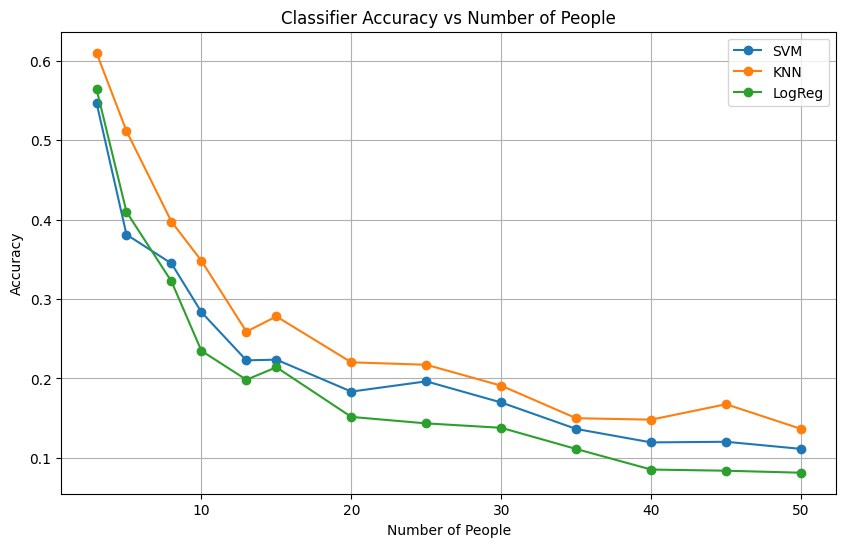

In [410]:
import matplotlib.pyplot as plt

# Make sure num_people is numeric
results_df['num_people'] = results_df['num_people'].astype(int)

# Plot accuracy vs num_people for each classifier
plt.figure(figsize=(10, 6))

for clf_name in results_df['classifier'].unique():
    subset = results_df[results_df['classifier'] == clf_name]
    # You can average across different images_per_person
    subset_avg = subset.groupby('num_people')['accuracy'].mean().reset_index()
    
    plt.plot(subset_avg['num_people'], subset_avg['accuracy'], marker='o', label=clf_name)

plt.xlabel("Number of People")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy vs Number of People")
plt.legend()
plt.grid(True)
plt.show()

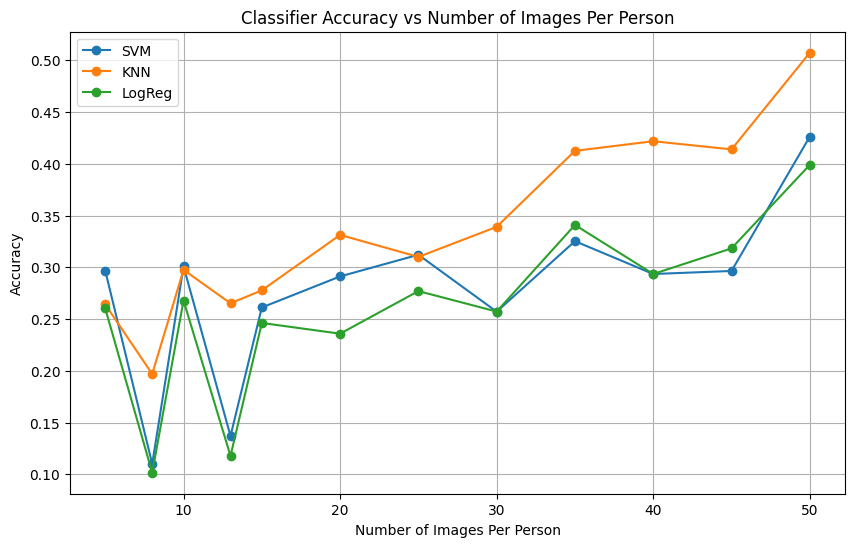

In [412]:
import matplotlib.pyplot as plt

# Make sure num_people is numeric
results_df['images_per_person'] = results_df['images_per_person'].astype(int)

plt.figure(figsize=(10, 6))

for clf_name in results_df['classifier'].unique():
    subset = results_df[results_df['classifier'] == clf_name]
    # You can average across different images_per_person
    subset_avg = subset.groupby('images_per_person')['accuracy'].mean().reset_index()
    
    plt.plot(subset_avg['images_per_person'], subset_avg['accuracy'], marker='o', label=clf_name)

plt.xlabel("Number of Images Per Person")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy vs Number of Images Per Person")
plt.legend()
plt.grid(True)
plt.show()

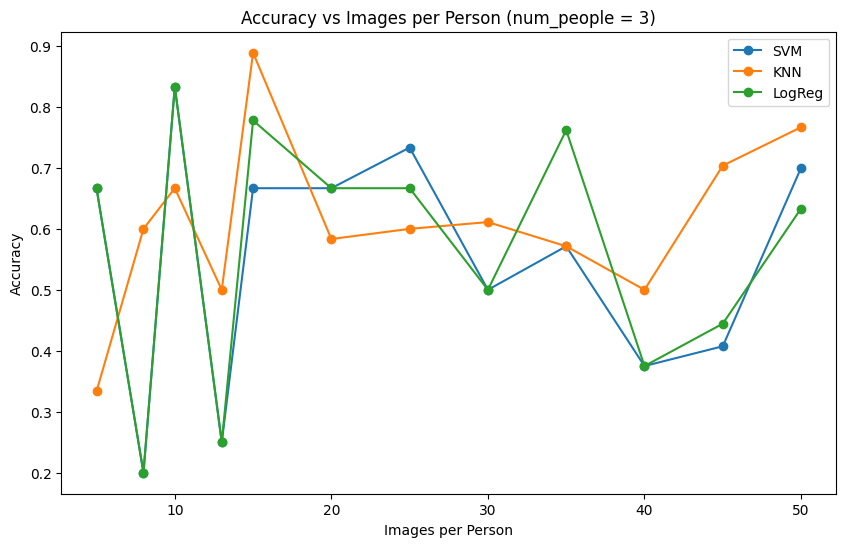

In [418]:
# get results_df of images per person at number of people equal to 5
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
subset = results_df[results_df["num_people"] == 3]

for clf_name in results_df['classifier'].unique():
    data = subset[subset["classifier"] == clf_name]
    plt.plot(data["images_per_person"], data["accuracy"], marker="o", label=clf_name)

plt.xlabel("Images per Person")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Images per Person (num_people = 3)")
plt.legend()
plt.show()

## Run 10 trials for generalization of result

In [422]:
import pandas as pd

range_num_people = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50]
range_min_images_per_person = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50] # 3 is dropped due to too small test sample

n_trials = 10

results = []

for num_people in range_num_people:
    for min_images_per_person in range_min_images_per_person:

        for trial in range(n_trials):

            print(f"[INFO] People={num_people}, Images={min_images_per_person}, Trial={trial+1}")

            embedding, labels = load_lfw_dataset(num_people, min_images_per_person)

            if len(embedding) == 0:
                continue

            num_classes = len(set(labels))
            num_samples = len(labels)
            test_size = int(num_samples * 0.2)

            # Skip invalid stratified split
            if test_size < num_classes:
                continue

            classifiers, X_train, X_test, y_train, y_test, le = train_model(embedding, labels)

            for name, clf in classifiers.items():

                accuracy, precision, recall, error_rate = predict(
                    name, clf, X_train, X_test, y_train, y_test
                )

                results.append({
                    "num_people": num_people,
                    "images_per_person": min_images_per_person,
                    "trial": trial + 1,
                    "classifier": name,
                    "classifier_info": f"Type: {type(clf).__name__}, Parameters: {clf.get_params()}",
                    "accuracy": accuracy,
                    "precision_macro": precision,
                    "error_rate": error_rate
                })

results_df = pd.DataFrame(results)

[INFO] People=3, Images=3, Trial=1
[INFO] People=3, Images=3, Trial=2
[INFO] People=3, Images=3, Trial=3
[INFO] People=3, Images=3, Trial=4
[INFO] People=3, Images=3, Trial=5
[INFO] People=3, Images=3, Trial=6
[INFO] People=3, Images=3, Trial=7
[INFO] People=3, Images=3, Trial=8
[INFO] People=3, Images=3, Trial=9
[INFO] People=3, Images=3, Trial=10
[INFO] People=3, Images=5, Trial=1
[INFO] Number of classes: 3
[INFO] Training samples: 12, Testing samples: 3
Classifier: SVM
Type: SVC
Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------
Accuracy: 66.67%
Precision (macro): 50.00%
Recall (macro): 66.67%
Error rate: 33.33%

Classifier: KNN
Type: KNeighborsClassifier
Parameters: {'algorithm': 'auto', 'leaf_size': 30, '

In [494]:
results_df.to_csv("results_without_unknowns_df.csv", index = False)

## Analysis

### Investigation

In [432]:
results_df

,num_people,images_per_person,trial,classifier,classifier_info,accuracy,precision_macro,error_rate
0,3,5,1,SVM,"Type: SVC, Parameters: {'C': 1.0, 'break_ties'...",0.666667,0.500000,0.333333
1,3,5,1,KNN,"Type: KNeighborsClassifier, Parameters: {'algo...",1.000000,1.000000,0.000000
2,3,5,1,LogReg,"Type: LogisticRegression, Parameters: {'C': 1....",0.666667,0.500000,0.333333
3,3,5,2,SVM,"Type: SVC, Parameters: {'C': 1.0, 'break_ties'...",0.000000,0.000000,1.000000
4,3,5,2,KNN,"Type: KNeighborsClassifier, Parameters: {'algo...",0.666667,0.500000,0.333333
...,...,...,...,...,...,...,...,...
3595,50,20,9,KNN,"Type: KNeighborsClassifier, Parameters: {'algo...",0.155000,0.196468,0.845000
3596,50,20,9,LogReg,"Type: LogisticRegression, Parameters: {'C': 1....",0.045000,0.039276,0.955000
3597,50,20,10,SVM,"Type: SVC, Parameters: {'C': 1.0, 'break_ties'...",0.130000,0.082843,0.870000
3598,50,20,10,KNN,"Type: KNeighborsClassifier, Parameters: {'algo...",0.125000,0.124738,0.875000


In [434]:
experiments = results_df[["num_people", "images_per_person"]].drop_duplicates().sort_values(
    ["num_people", "images_per_person"]
)

print(experiments.to_string(index=False))

 num_people  images_per_person
          3                  5
          3                  8
          3                 10
          3                 13
          3                 15
          3                 20
          3                 25
          3                 30
          3                 35
          3                 40
          3                 45
          3                 50
          5                  5
          5                  8
          5                 10
          5                 13
          5                 15
          5                 20
          5                 25
          5                 30
          5                 35
          5                 40
          5                 45
          5                 50
          8                  5
          8                  8
          8                 10
          8                 13
          8                 15
          8                 20
          8                 25
        

### Plots

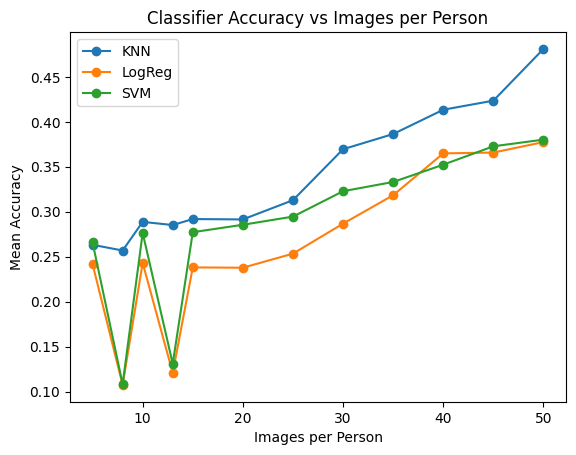

In [425]:
images_analysis = results_df.groupby(
    ["images_per_person","classifier"]
)["accuracy"].mean().reset_index()

for clf in images_analysis["classifier"].unique():

    subset = images_analysis[images_analysis["classifier"] == clf]

    plt.plot(
        subset["images_per_person"],
        subset["accuracy"],
        marker="o",
        label=clf
    )

plt.xlabel("Images per Person")
plt.ylabel("Mean Accuracy")
plt.title("Classifier Accuracy vs Images per Person")
plt.legend()
plt.show()

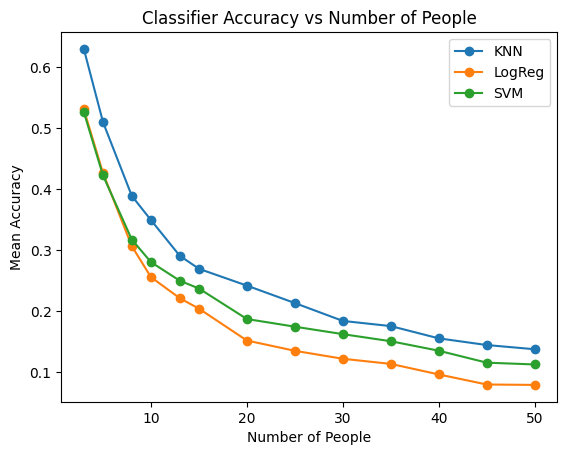

In [426]:
people_analysis = results_df.groupby(
    ["num_people","classifier"]
)["accuracy"].mean().reset_index()

for clf in people_analysis["classifier"].unique():

    subset = people_analysis[people_analysis["classifier"] == clf]

    plt.plot(
        subset["num_people"],
        subset["accuracy"],
        marker="o",
        label=clf
    )

plt.xlabel("Number of People")
plt.ylabel("Mean Accuracy")
plt.title("Classifier Accuracy vs Number of People")
plt.legend()
plt.show()

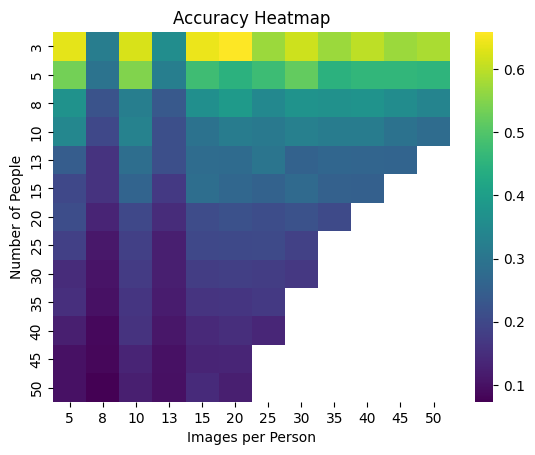

In [427]:
pivot = results_df.groupby(
    ["num_people","images_per_person"]
)["accuracy"].mean().unstack()

import seaborn as sns

sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Images per Person")
plt.ylabel("Number of People")
plt.title("Accuracy Heatmap")
plt.show()

## Miss

In [298]:
import numpy as np
from sklearn.model_selection import train_test_split

# Convert lists to numpy arrays
X = np.array(lfw_embeddings)  # shape: (n_samples, 128) if using your FaceEmbedder
y = np.array(lfw_labels)      # numeric labels

# ----------------- Encode labels -----------------
le = LabelEncoder()
y_enc = le.fit_transform(y)  # now labels are 0..n_classes-1

# ----------------- Train/test split -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

print(f"[INFO] Number of classes: {len(le.classes_)}")
print(f"[INFO] Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

[INFO] Number of classes: 10
[INFO] Training samples: 79, Testing samples: 20


Classifier: SVM
Type: SVC
Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------
Accuracy: 40.00%
Precision (macro): 33.00%
Recall (macro): 40.00%
Error rate: 60.00%



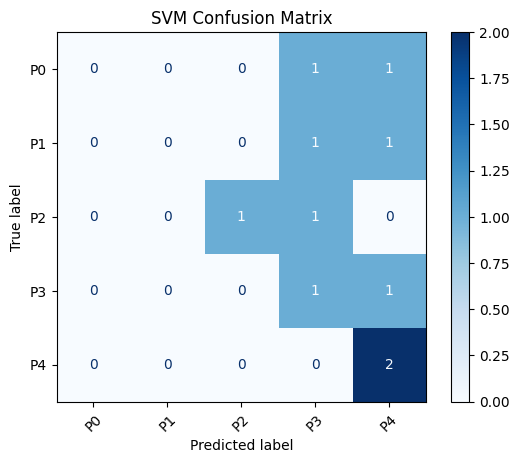

Classifier: KNN
Type: KNeighborsClassifier
Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
------------------------------------
Accuracy: 50.00%
Precision (macro): 63.33%
Recall (macro): 50.00%
Error rate: 50.00%



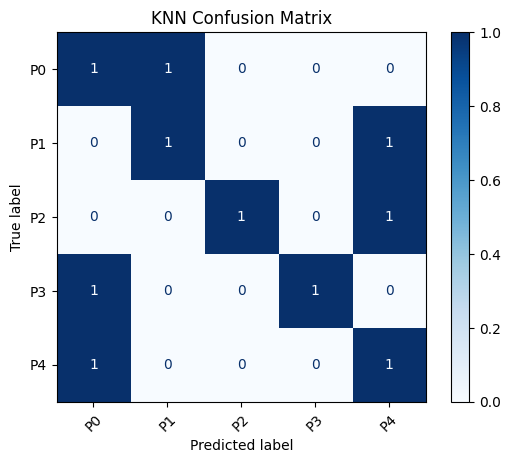

Classifier: LogReg
Type: LogisticRegression
Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
------------------------------------
Accuracy: 30.00%
Precision (macro): 25.00%
Recall (macro): 30.00%
Error rate: 70.00%



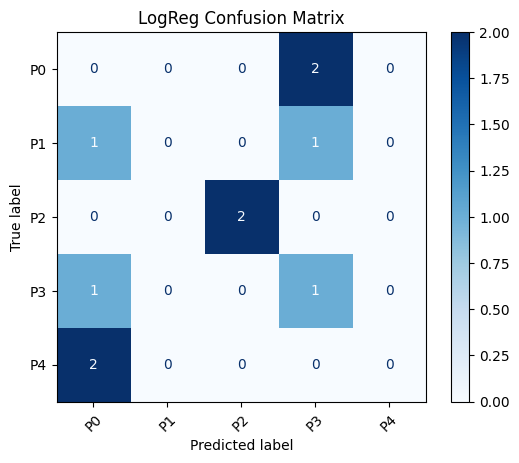

In [294]:
# ----------------- Train multiple classifiers -----------------
classifiers = {
    "SVM": SVC(C=1.0, kernel="linear", probability=True), #, class_weight = 'balanced'
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "LogReg": LogisticRegression(max_iter=500)
}

# Optional: remap labels to consecutive numbers (0,1,...,NUM_PEOPLE-1)
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_mapped = np.array([label_map[label] for label in y])

from sklearn.metrics import accuracy_score, precision_score, recall_score

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    error_rate = 1 - accuracy

    print("====================================")
    print(f"Classifier: {name}")
    print(f"Type: {type(clf).__name__}")
    if hasattr(clf, 'get_params'):
        print(f"Parameters: {clf.get_params()}")
    print("------------------------------------")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision (macro): {precision*100:.2f}%")
    print(f"Recall (macro): {recall*100:.2f}%")
    print(f"Error rate: {error_rate*100:.2f}%")
    print("====================================\n")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"P{i}" for i in range(len(unique_labels))])
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Convert lists to numpy arrays
X = np.array(lfw_embeddings)
y = np.array(lfw_labels)

# Optional: remap labels to consecutive numbers (0,1,...,NUM_PEOPLE-1)
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_mapped = np.array([label_map[label] for label in y])

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_mapped, test_size=0.2, stratify=y_mapped, random_state=42
)

# Define classifiers
classifiers = {
    "SVM": SVC(kernel="linear", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "LogReg": LogisticRegression(max_iter=500)
}

# Train, predict, and plot confusion matrix
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"P{i}" for i in range(len(unique_labels))])
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

## Add Local Dataset

In [91]:
# ==========================================
# 2. Combine with your local dataset
with open("embeddings.pkl", "rb") as f:
    local_data = pickle.load(f)

local_embeddings = local_data["embeddings"]
local_labels = local_data["labels"]

# Encode your local labels to integers
le_local = LabelEncoder()
local_labels_encoded = le_local.fit_transform(local_labels)

print(f"[INFO] Local dataset: {len(local_embeddings)} embeddings, {len(le_local.classes_)} unique people")

[INFO] Local dataset: 358 embeddings, 3 unique people


In [105]:
# ==========================================
# 3. Prepare full dataset for classifier
lfw_labels_named = [label_names[i] for i in labels]
print(labels)
X = np.array(lfw_embeddings + local_embeddings)
y = np.array(lfw_labels_named + local_labels_encoded.tolist())

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"[INFO] Total dataset: {X.shape[0]} samples, {len(le.classes_)} unique labels")

[11  4  2 ...  3 11  5]
[INFO] Total dataset: 1918 samples, 15 unique labels


In [103]:
print(local_labels_encoded)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [95]:
# ==========================================
# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)


=== SVM Results ===
              precision    recall  f1-score   support

           0       1.00      0.43      0.61        23
           1       0.96      0.34      0.50        79
           2       0.94      0.51      0.66        57
           3       0.34      1.00      0.50       106
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00        11
           9       0.00      0.00      0.00        12
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        29

    accuracy                           0.45       384
   macro avg       0.27      0.19      0.19       384
weighted avg       0.49      0.45      0.38       384



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


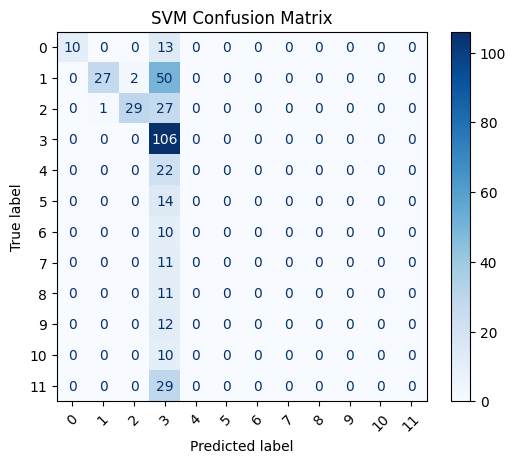


=== KNN Results ===
              precision    recall  f1-score   support

           0       0.42      0.61      0.50        23
           1       0.58      0.76      0.66        79
           2       0.64      0.67      0.66        57
           3       0.53      0.69      0.60       106
           4       0.17      0.09      0.12        22
           5       0.50      0.07      0.12        14
           6       0.25      0.10      0.14        10
           7       0.00      0.00      0.00        11
           8       0.25      0.09      0.13        11
           9       0.80      0.33      0.47        12
          10       0.60      0.30      0.40        10
          11       0.41      0.24      0.30        29

    accuracy                           0.53       384
   macro avg       0.43      0.33      0.34       384
weighted avg       0.50      0.53      0.49       384



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


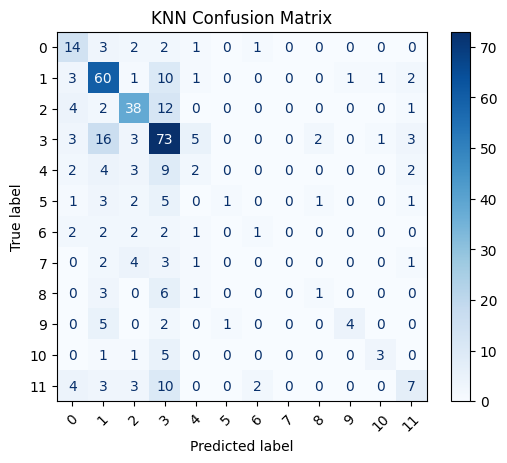


=== LogReg Results ===
              precision    recall  f1-score   support

           0       1.00      0.43      0.61        23
           1       0.96      0.34      0.50        79
           2       0.94      0.51      0.66        57
           3       0.34      1.00      0.50       106
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00        11
           9       0.00      0.00      0.00        12
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        29

    accuracy                           0.45       384
   macro avg       0.27      0.19      0.19       384
weighted avg       0.49      0.45      0.38       384



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


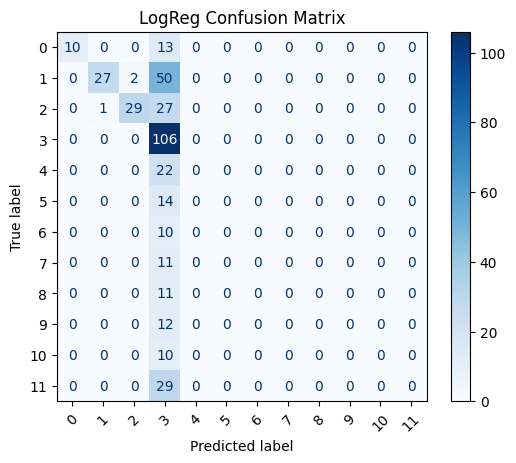

In [97]:
# ==========================================
# 5. Train multiple classifiers
classifiers = {
    "SVM": SVC(kernel="linear", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "LogReg": LogisticRegression(max_iter=500)
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"\n=== {name} Results ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    
    results[name] = clf

In [ ]:
# ==========================================
# 6. Distance-based classifier
from scipy.spatial.distance import cosine

DIST_THRESHOLD = 0.5
y_pred_dist = []

for emb in X_test:
    sims = 1 - np.array([cosine(emb, e) for e in X_train])
    best_idx = np.argmax(sims)
    best_sim = sims[best_idx]
    label = y_train[best_idx] if best_sim >= DIST_THRESHOLD else -1  # -1 = Unknown
    y_pred_dist.append(label)

# Map -1 to Unknown label for display
y_true_labels = [str(le.classes_[i]) for i in y_test]
y_pred_labels = [str(le.classes_[i]) if i != -1 else "Unknown" for i in y_pred_dist]

print("\n=== Distance-based Classifier Results ===")
print(classification_report(y_true_labels, y_pred_labels, labels=list(le.classes_.astype(str))+["Unknown"]))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=list(le.classes_.astype(str))+["Unknown"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(le.classes_.astype(str))+["Unknown"])
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Distance-based Classifier Confusion Matrix")
plt.show()

In [ ]:
# ==========================================
# Final: Save completed classifier to load them later for prediction

# With Unknown Identities

## Load Data

In [476]:
def load_lfw_dataset_with_unknowns(num_people, min_images_per_person, num_unknown=5):

    import random
    import cv2
    from collections import defaultdict

    person_to_indices = defaultdict(list)

    # Shuffle dataset order
    all_indices = list(range(len(lfw.images)))
    random.shuffle(all_indices)

    for idx in all_indices:
        label_idx = lfw.target[idx]
        person_name = lfw.target_names[label_idx]
        person_to_indices[person_name].append(idx)

    eligible_people = [
        p for p, idxs in person_to_indices.items()
        if len(idxs) >= min_images_per_person
    ]

    if len(eligible_people) < num_people + num_unknown:
        return [], [], [], []

    # Select known identities
    known_people = random.sample(eligible_people, num_people)

    # Select unknown identities
    remaining_people = list(set(eligible_people) - set(known_people))
    unknown_people = random.sample(remaining_people, num_unknown)

    X_train, y_train = [], []
    X_test, y_test = [], []

    # -----------------------
    # Known people
    # -----------------------
    for person in known_people:

        indices = person_to_indices[person]
        selected = random.sample(indices, min_images_per_person)

        split = int(len(selected) * 0.8)

        train_idx = selected[:split]
        test_idx = selected[split:]

        for idx in train_idx:
            img = lfw.images[idx]

            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            img = cv2.resize(img, (300,300))
            emb = embedder.get_embedding(img)

            X_train.append(emb)
            y_train.append(person)

        for idx in test_idx:
            img = lfw.images[idx]

            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            img = cv2.resize(img, (300,300))
            emb = embedder.get_embedding(img)

            X_test.append(emb)
            y_test.append(person)

    # -----------------------
    # Unknown people
    # -----------------------
    for person in unknown_people:

        indices = person_to_indices[person]

        # take some samples only for test
        selected = random.sample(indices, min_images_per_person)

        for idx in selected:

            img = lfw.images[idx]

            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            img = cv2.resize(img, (300,300))
            emb = embedder.get_embedding(img)

            X_test.append(emb)
            y_test.append("unknown")

    return X_train, X_test, y_train, y_test

## Predict

In [478]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def predict_open_set(name, clf, X_train, y_train, X_test, y_test, le, threshold=0.5):
    """
    Predict with open-set handling.
    Probabilities below threshold are labeled as 'unknown'.
    Returns accuracy, precision, recall, error_rate
    """
    import numpy as np
    
    clf.fit(X_train, y_train)
    X_test = np.array(X_test)

    # Predict probabilities
    probs = clf.predict_proba(X_test)

    y_pred = []
    for p in probs:
        if np.max(p) < threshold:
            y_pred.append("unknown")
        else:
            y_pred.append(le.inverse_transform([np.argmax(p)])[0])

    # Ensure y_test also has 'unknown' as a label
    y_true = y_test

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Macro precision / recall
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    # Error rate
    error_rate = 1 - accuracy

    # Print summary
    print("====================================")
    print(f"Classifier: {name}")
    print(f"Type: {type(clf).__name__}")
    if hasattr(clf, 'get_params'):
        print(f"Parameters: {clf.get_params()}")
    print("------------------------------------")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision (macro): {precision*100:.2f}%")
    print(f"Recall (macro): {recall*100:.2f}%")
    print(f"Error rate: {error_rate*100:.2f}%")
    print("====================================\n")

    return accuracy, precision, recall, error_rate

## Run 10 Trials

In [480]:
import pandas as pd

range_num_people = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50]
range_min_images_per_person = [3, 5, 8, 10, 13, 15, 20, 25, 30, 35, 40, 45, 50] # 3 is dropped due to too small test sample

n_trials = 10

results_with_unknowns = []

for num_people in range_num_people:
    for min_images_per_person in range_min_images_per_person:

        for trial in range(n_trials):

            print(f"[INFO] People={num_people}, Images={min_images_per_person}, Trial={trial+1}")

            X_train, X_test, y_train, y_test = load_lfw_dataset_with_unknowns(num_people, min_images_per_person)

            if len(embedding) == 0:
                continue

            num_classes = len(set(labels))
            num_samples = len(labels)
            test_size = int(num_samples * 0.2)

            # Skip invalid stratified split
            if test_size < num_classes:
                continue

            classifiers, X_train, X_test, y_train, y_test, le = train_model(embedding, labels)

            for name, clf in classifiers.items():

                accuracy, precision, recall, error_rate = predict_open_set(
                    name, clf, X_train, X_test, y_train, y_test
                )

                results.append({
                    "num_people": num_people,
                    "images_per_person": min_images_per_person,
                    "trial": trial + 1,
                    "classifier": name,
                    "classifier_info": f"Type: {type(clf).__name__}, Parameters: {clf.get_params()}",
                    "accuracy": accuracy,
                    "precision_macro": precision,
                    "error_rate": error_rate
                })

results_with_unknowns_df = pd.DataFrame(results)

[INFO] People=3, Images=3, Trial=1
[INFO] People=3, Images=3, Trial=2
[INFO] People=3, Images=3, Trial=3
[INFO] People=3, Images=3, Trial=4
[INFO] People=3, Images=3, Trial=5
[INFO] People=3, Images=3, Trial=6
[INFO] People=3, Images=3, Trial=7
[INFO] People=3, Images=3, Trial=8
[INFO] People=3, Images=3, Trial=9
[INFO] People=3, Images=3, Trial=10
[INFO] People=3, Images=5, Trial=1
[INFO] People=3, Images=5, Trial=2
[INFO] People=3, Images=5, Trial=3
[INFO] People=3, Images=5, Trial=4
[INFO] People=3, Images=5, Trial=5
[INFO] People=3, Images=5, Trial=6
[INFO] People=3, Images=5, Trial=7
[INFO] People=3, Images=5, Trial=8
[INFO] People=3, Images=5, Trial=9
[INFO] People=3, Images=5, Trial=10
[INFO] People=3, Images=8, Trial=1
[INFO] People=3, Images=8, Trial=2
[INFO] People=3, Images=8, Trial=3
[INFO] People=3, Images=8, Trial=4
[INFO] People=3, Images=8, Trial=5
[INFO] People=3, Images=8, Trial=6
[INFO] People=3, Images=8, Trial=7
[INFO] People=3, Images=8, Trial=8
[INFO] People=3, I

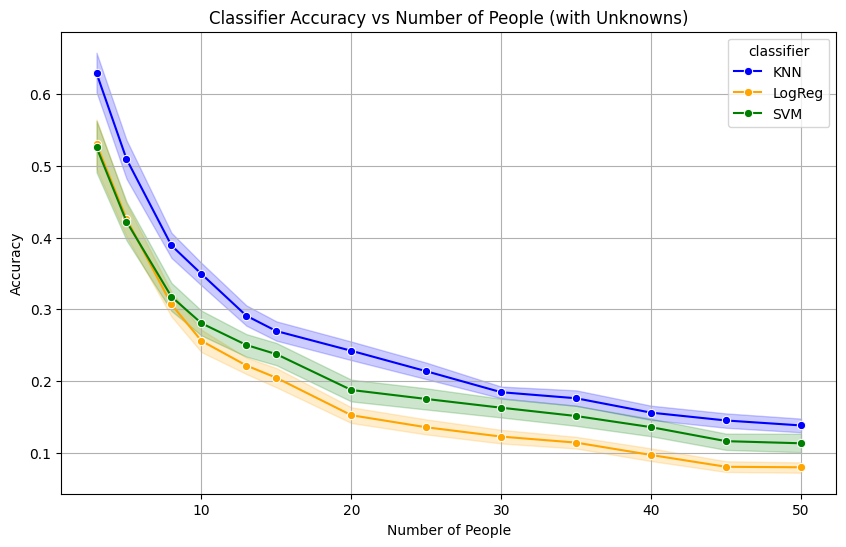

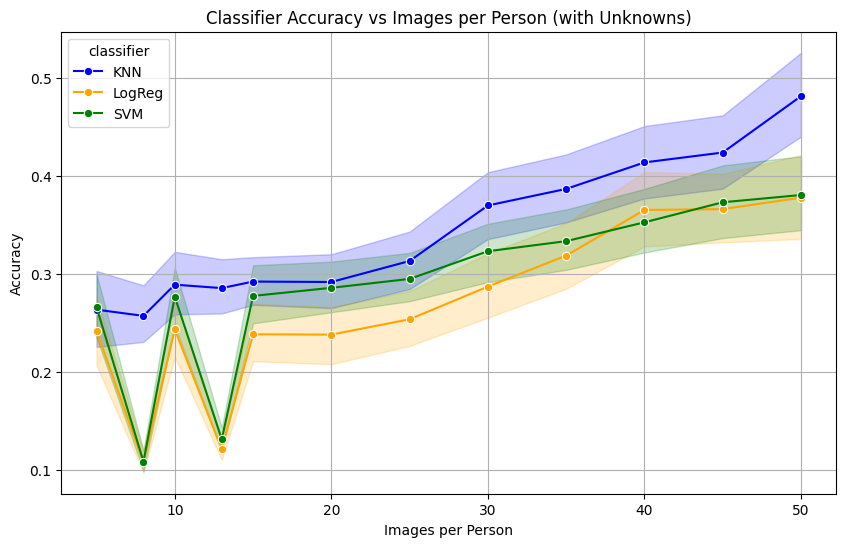

In [486]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define color palette
palette = {
    "KNN": "blue",
    "LogReg": "orange",
    "SVM": "green"
}

# Define order
order = ["KNN", "LogReg", "SVM"]

# Accuracy vs Number of People
plt.figure(figsize=(10,6))
sns.lineplot(
    data=results_df,
    x="num_people",
    y="accuracy",
    hue="classifier",
    hue_order=order,
    palette=palette,
    marker="o"
)
plt.title("Classifier Accuracy vs Number of People (with Unknowns)")
plt.xlabel("Number of People")
plt.ylabel("Accuracy")
# plt.ylim(0,1)
plt.grid(True)
plt.show()

# Accuracy vs Images per Person
plt.figure(figsize=(10,6))
sns.lineplot(
    data=results_df,
    x="images_per_person",
    y="accuracy",
    hue="classifier",
    hue_order=order,
    palette=palette,
    marker="o"
)
plt.title("Classifier Accuracy vs Images per Person (with Unknowns)")
plt.xlabel("Images per Person")
plt.ylabel("Accuracy")
# plt.ylim(0,1)
plt.grid(True)
plt.show()

In [492]:
results_with_unknowns_df.to_csv("results_with_unknowns_df.csv", index = False)

## Improve KNN

Need this to work well for case of increased number of people with small samples of images per person (check average frames captures gained from each person's video)